# Sistemas de Recomendación - Tu Futuro según la Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

# EDA

In [3]:
df = pd.read_csv('../data/raw/adult-census-income.csv')
df.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


Este dataset incluye variables como:

- Edad   
- Nivel educativo   
- Estado civil   
- Ocupación   
- Horas trabajadas por semana   
- Sexo   
- País de origen   
- Ingreso anual (>50K o <=50K)   

In [4]:
df.shape

(32561, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [7]:
df_original = df.copy()
df_original

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


## Limpieza de datos

### Eliminar duplicados

In [8]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
32556    False
32557    False
32558    False
32559    False
32560    False
Length: 32561, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(24)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(32537, 15)

### Eliminar información irrelevante

In [12]:
df = df.drop(columns=['fnlwgt'])

In [13]:
df.head(5)

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


> La variable `fnlwgt` fue eliminada ya que representa un peso estadístico del muestreo censal y no una característica inherente al individuo, por lo que no aporta información relevante para un sistema de recomendación basado en perfiles.

## Análisis de Variables

Análisis de Variables Numéricas

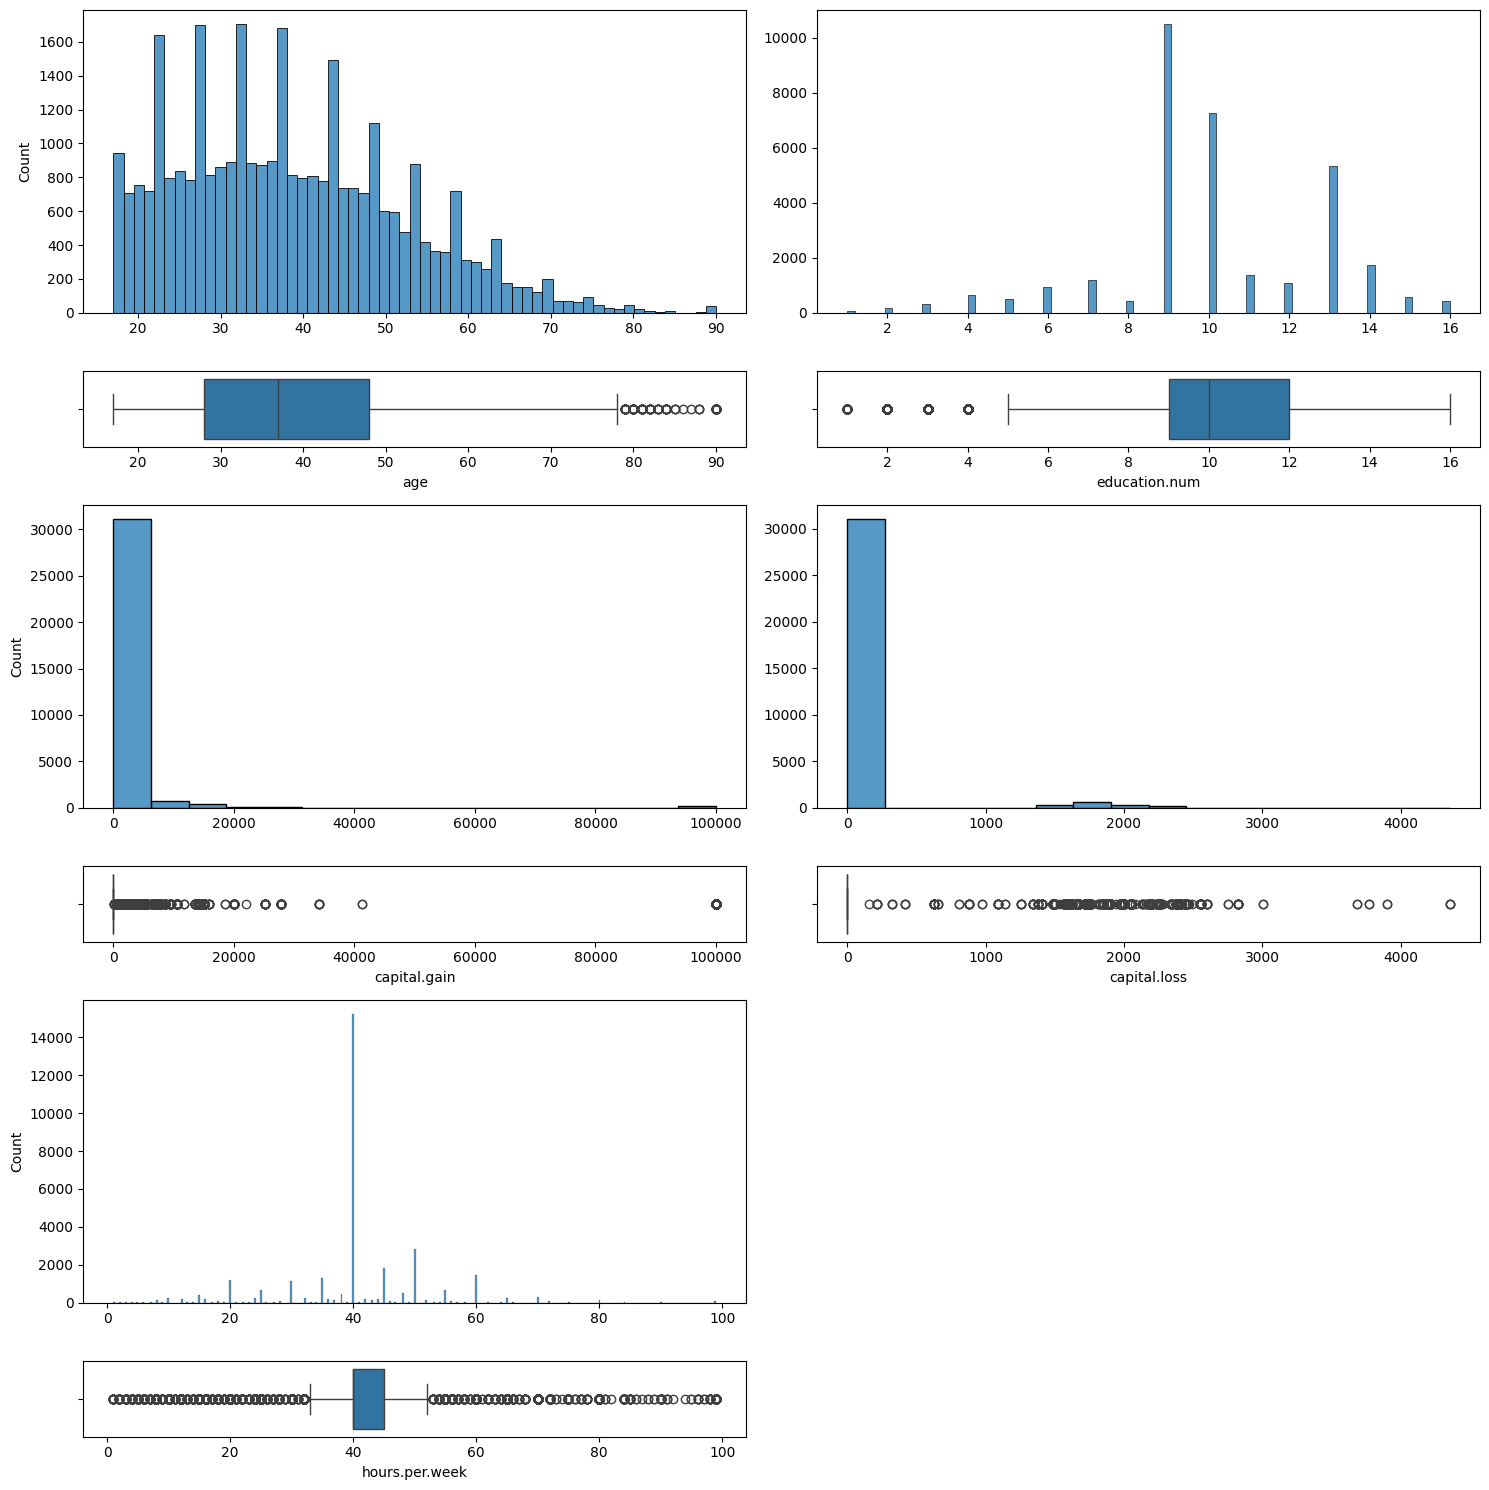

In [14]:
fig, axis = plt.subplots(6, 2, figsize=(15, 15), gridspec_kw={'height_ratios': [4, 1, 4, 1, 4, 1]})

# Creating a multiple figure with histograms and box plots
sns.histplot(ax=axis[0, 0], data=df, x='age').set(xlabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x='age')
sns.histplot(ax=axis[0, 1], data=df, x='education.num').set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x='education.num')
sns.histplot(ax=axis[2, 0], data=df, x='capital.gain').set(xlabel=None)
sns.boxplot(ax=axis[3, 0], data=df, x='capital.gain')
sns.histplot(ax=axis[2, 1], data=df, x='capital.loss').set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[3, 1], data=df, x='capital.loss')
sns.histplot(ax=axis[4, 0], data=df, x='hours.per.week').set(xlabel=None)
sns.boxplot(ax=axis[5, 0], data=df, x='hours.per.week')

# Remove an axis (subplot) from the figure
fig.delaxes(axis[4,1])
fig.delaxes(axis[5,1])

# Adjust the layout
plt.tight_layout()
plt.show()

#### Análisis de Variables Categóricas

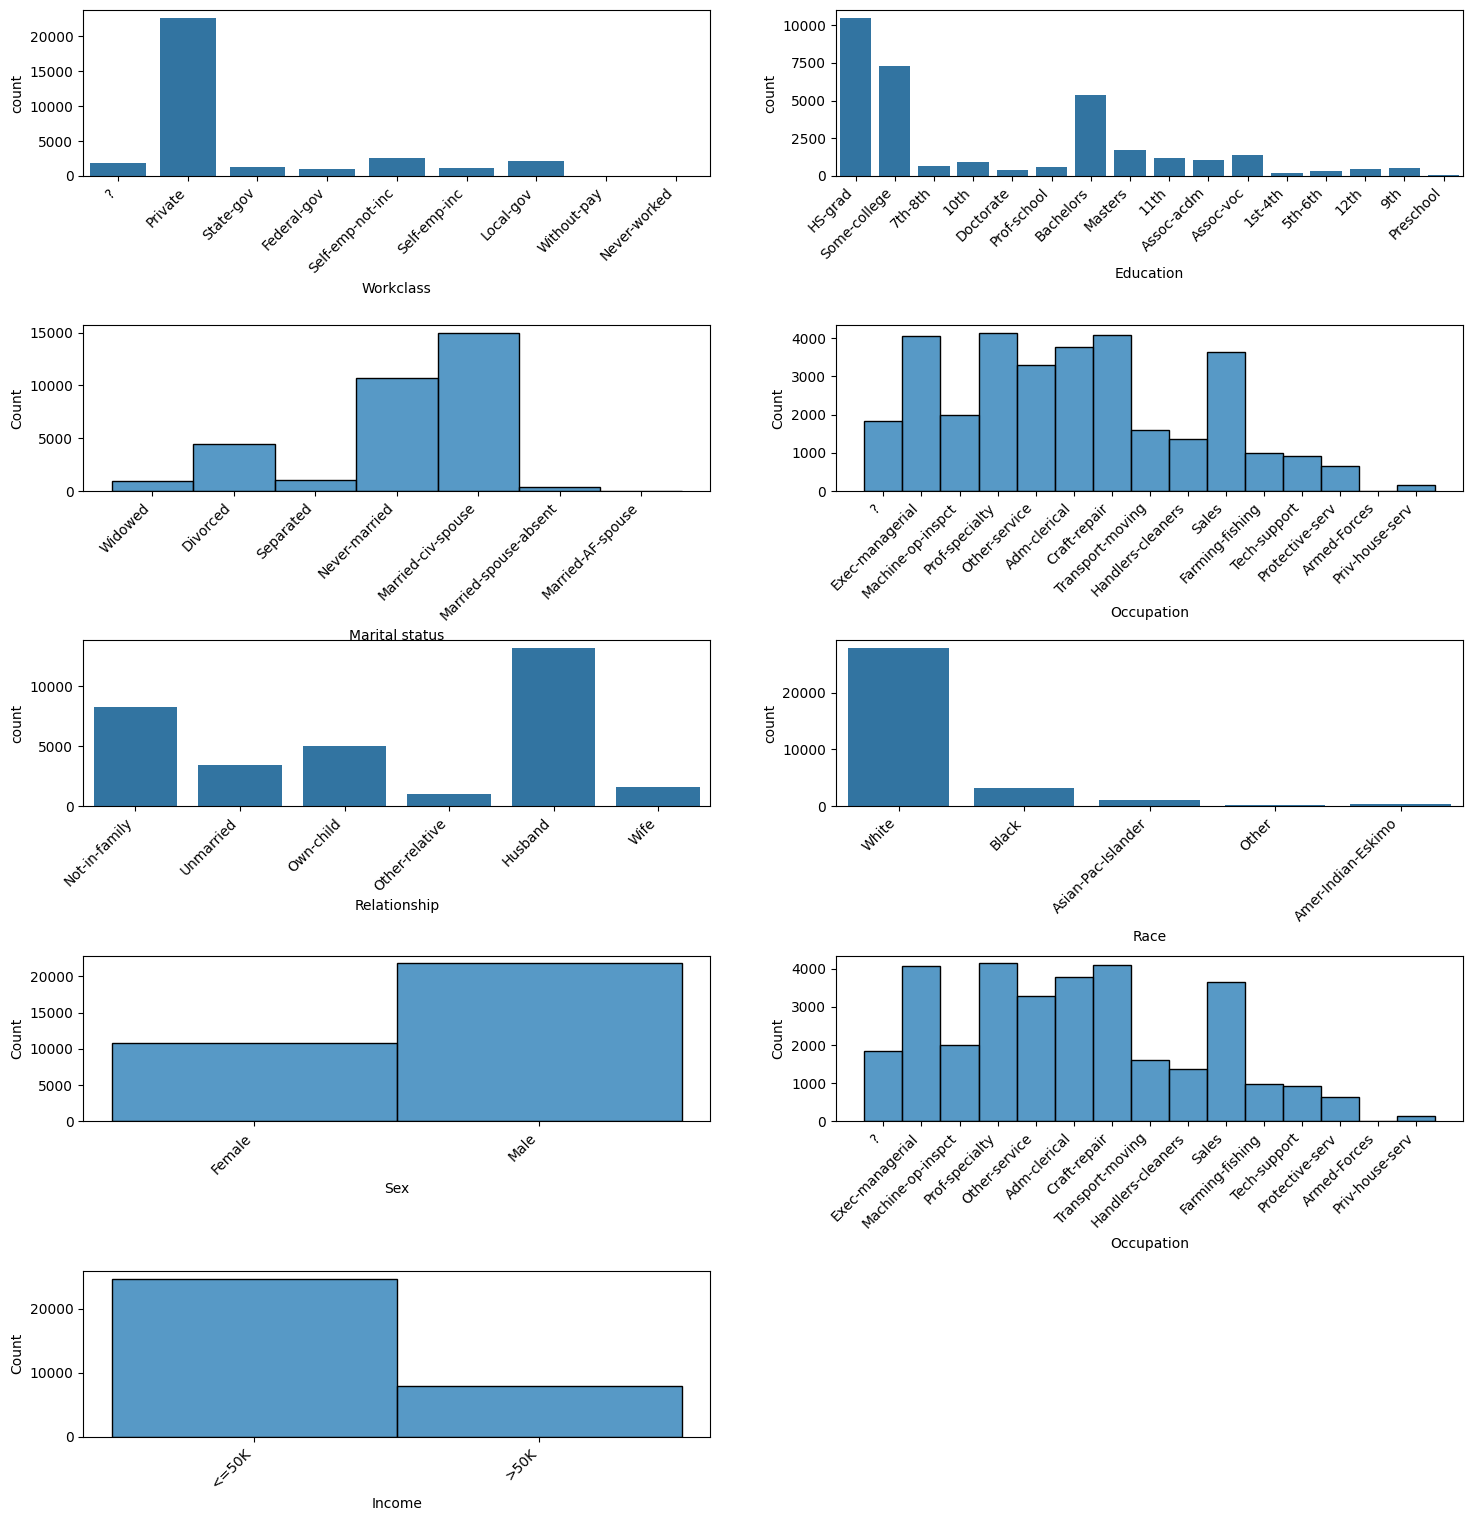

In [15]:
fig, axis = plt.subplots(5, 2, figsize=(15, 15))

sns.countplot(ax=axis[0,0], data=df, x='workclass')
axis[0,0].set_xlabel('Workclass')
sns.countplot(ax=axis[0,1], data=df, x='education')
axis[0,1].set_xlabel('Education')
sns.histplot(ax=axis[1,0], data=df, x='marital.status')
axis[1,0].set_xlabel('Marital status')
sns.histplot(ax=axis[1,1], data=df, x='occupation').set(xlabel=None)
axis[1,1].set_xlabel('Occupation')
sns.countplot(ax=axis[2,0], data=df, x='relationship')
axis[2,0].set_xlabel('Relationship')
sns.countplot(ax=axis[2,1], data=df, x='race')
axis[2,1].set_xlabel('Race')
sns.histplot(ax=axis[3,0], data=df, x='sex')
axis[3,0].set_xlabel('Sex')
sns.histplot(ax=axis[3,1], data=df, x='occupation').set(xlabel=None)
axis[3,1].set_xlabel('Occupation')
sns.histplot(ax=axis[4,0], data=df, x='income').set(xlabel=None)
axis[4,0].set_xlabel('Income')

plt.tight_layout()
plt.draw()

fig.delaxes(axis[4,1])

for ax in axis.flat:
    labels = ax.get_xticklabels()
    if labels:
        for label in labels:
            label.set_rotation(45)
            label.set_ha('right')

plt.subplots_adjust(hspace=0.9, wspace=0.2)
plt.show()

#### Observaciones:
> Al visualizar todas las columnas, podemos observar que existen varios valores mal configurados, como '?'.
> En el gráfico se observa que el conjunto de datos contiene un mayor número de hombres que de mujeres.
> La mayoría de las personas tiene entre 25 y 50 años.

Tenemos que detectar los valores mal codificados, en este caso '?' y reemplazarlos. 

In [16]:
(df=='?').sum()

age                  0
workclass         1836
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     582
income               0
dtype: int64

In [17]:
df = df.replace('?', np.nan)

In [18]:
df.head(20)

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,NaN,>50K


In [19]:
df = df.dropna()

In [20]:
df.isna().sum()

age               0
workclass         0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [21]:
df.head(20)

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
10,45,Private,Doctorate,16,Divorced,Prof-specialty,Unmarried,Black,Female,0,3004,35,United-States,>50K
11,38,Self-emp-not-inc,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,0,2824,45,United-States,>50K
12,52,Private,Bachelors,13,Widowed,Other-service,Not-in-family,White,Female,0,2824,20,United-States,>50K


#### Observaciones:
> Los valores faltantes fueron eliminados del conjunto de datos, ya que representan una fracción reducida del total y su eliminación no compromete la representatividad del dataset. Esta decisión permite simplificar el preprocesamiento y evitar la introducción de ruido en el sistema de recomendación.

In [22]:
(df==0).sum()

age                   0
workclass             0
education             0
education.num         0
marital.status        0
occupation            0
relationship          0
race                  0
sex                   0
capital.gain      27601
capital.loss      28712
hours.per.week        0
native.country        0
income                0
dtype: int64

En el conjunto de datos, los valores cero aparecen únicamente en las columnas `capital.gain` y `capital.loss`. Estos son datos reales e importantes, por lo que no es necesario eliminarlos ni reemplazarlos.

In [23]:
df['income'].value_counts()

income
<=50K    22633
>50K      7506
Name: count, dtype: int64

In [24]:
df['income'] = df['income'].map({'<=50K': 0,
                                 '>50K': 1})

In [25]:
df['income'].value_counts()

income
0    22633
1     7506
Name: count, dtype: int64

In [26]:
df['income'].dtype

dtype('int64')

#### Observaciones:
> La variable income, originalmente categórica, fue transformada en una variable binaria donde el valor 1 indica ingresos anuales superiores a 50.000 dólares y el valor 0 indica ingresos iguales o inferiores. Esta variable se utilizó exclusivamente como variable objetivo del sistema de recomendación.

#### Split

In [27]:
X = df.drop('income', axis=1)
y = df['income']

#### Enconding: One-Hot Encoding

Para las variables categóricas utilizamos el metodo One Hot encoding porque tenemos pocas categorías (menos de 10) y no tienen order real.

In [28]:
# Generate a list with the names of the categorical columns
categorical_variables = X.select_dtypes(include=['object']).columns

# We create the encoder instance
onehot_encoder = OneHotEncoder(sparse_output=False)

onehot_encoder = onehot_encoder.fit_transform(X[categorical_variables])

encoded_df = pd.DataFrame(onehot_encoder,
                          columns=onehot_encoder.get_feature_names_out(categorical_variables),
                          index=X.index)

X = pd.concat([X.drop(categorical_variables, axis=1), encoded_df], axis=1)


AttributeError: 'numpy.ndarray' object has no attribute 'get_feature_names_out'